# **Methods**

In [61]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import random

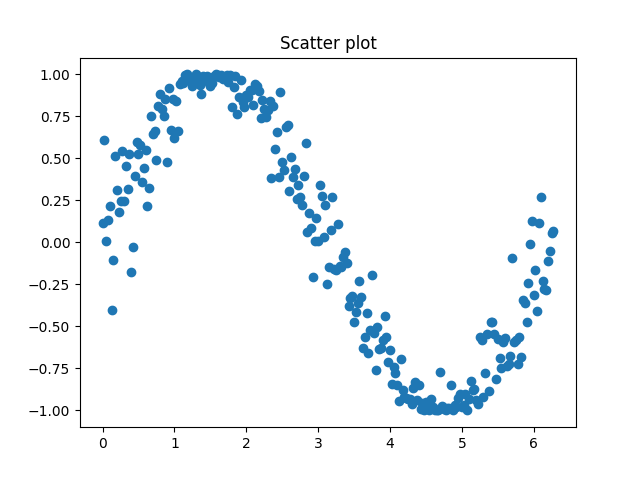

In [62]:
x = np.arange(0, 2*np.pi, 0.025)
y = np.array([np.sin(e + np.random.normal(0, 0.2)) for e in x])

# display(x.shape, y.shape)
# display(x, y)
fig = plt.figure()
plt.title("Scatter plot")
plt.scatter(x, y)

In [63]:
# NORMALIZE DATA for one feature
max_x = np.amax(x)      
min_x = np.amin(x)
    
x = np.array([(e - min_x)/(max_x - min_x) for e in x])

max_y = np.amax(y)
min_y = np.amin(y)
y = np.array([( e - min_y)/(max_y - min_y) for e in y])

# display(x.shape, y.shape)
# display(x, y)

In [64]:
# 70% for train and 30% test
m, = y.shape
idx = np.array(np.arange(m))
include_idx = set(np.random.choice(idx, size = int(0.7*m), replace=False))
mask = np.array([(i in include_idx) for i in range(m)])

trainX = x[mask]
testX = x[~mask]

trainY = y[mask]
testY = y[~mask]

# display(trainX.shape, testX.shape)
# display(trainY.shape, testY.shape)

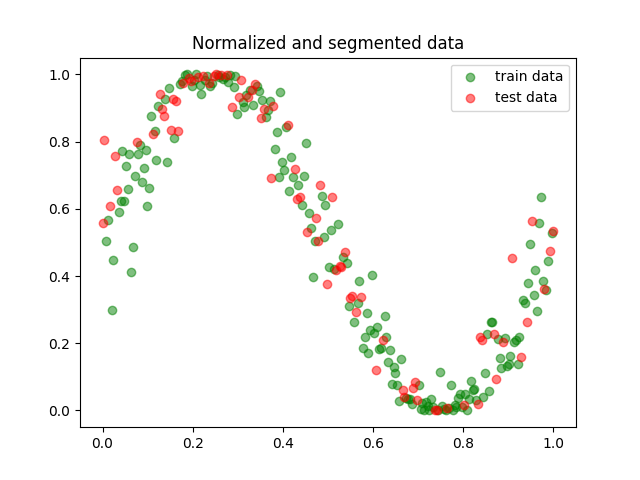

In [65]:
fig = plt.figure()
plt.title("Normalized and segmented data")
plt.scatter(trainX, trainY, color="green", alpha=0.5, label="train data")
plt.scatter(testX, testY, color="red", alpha=0.5, label="test data")
plt.legend()

## **Hypothesis**

$$ h(x_i) = w_0 + x_i^1 w_1 + x_i^2 w_2 + ... + + x_i^p w_p $$
$$ h(x_i) = \overline{x} . w^t $$


In [66]:
def h(x, w):
  return np.sum(np.multiply(x, w))

### **L1 Regularization: Lasso Regresssion**

**LASSO:** Least Absolute Shrinkage and Selection Operator

$$\lambda_i * \sum_{j=1}^{p} | w_j | $$

In [67]:
def L1_reg(w, lambdita):
    return np.sum(np.absolute(w)) * lambdita / len(w)

### **L2 Regularization: Ridge Regression**

$$\frac{\lambda}{n} * \sum_{j=1}^{p} (w_j)^2$$

In [68]:
def L2_Reg(w, lambdita):
    return np.sum(np.square(w)/len(w)) * lambdita 

The key difference between these techniques is that Lasso shrinks the less important feature’s coefficient to zero thus, removing some feature altogether. So, this works well for feature selection in case we have a huge number of features.

## **Loss Function for Regression Algorithms**

Mean Squared Error is preferred to use when **there are low outliers in the data**. This is one of the drawbacks of MSE.

$$\text{MSE} = \frac{1}{2m} \sum_{i=1}^{m} (y^{(i)} - \overline{y}^{(i)})^2$$

In [69]:
def MSE(y, x, w):
  m, = y.shape
  y_pred = np.array([h(x[j,:], w) for j in range(m)])
  
  return np.sum(np.square(y - y_pred)/(2.0*m))

MAE is preferred to use **when there is a chance of having outliers in the data**. This is one of the Advantages of MAE. Using **standardized data is efficient** for better optimization using this loss.

$$\text{MAE} = \frac{1}{m} \sum_{i=1}^{m} \mid (y^{(i)} - \overline{y}^{(i)}) \mid$$

In [70]:
def MAE(y, x, w):
    m, = y.shape
    y_predict = np.array([h(x[j,:], w) for j in range(m)])
    return np.sum([abs(diff)/m for diff in y - y_predict])

Huber Loss can be interpreted as a combination of the Mean squared loss function and Mean Absolute Error.

Huber loss brings the best of both MSE and MAE.

The δ term is a hyper-parameter for **Hinge Loss**.

$$
\text{Hubber Loss} =
\begin{cases} 
    \frac{1}{2} (y^{(i)} - \overline{y}^{(i)})^2,  & \text{if }  (y^{(i)} - \overline{y}^{(i)}) \leq \delta\\
    \delta (\mid (y^{(i)} - \overline{y}^{(i)}) \mid - \frac{1}{2} \delta) & \text{otherwise}
\end{cases}
$$

In [71]:
def HubberLoss(y, x, w, hyper):
    m, = y.shape
    y_predict = np.array([h(x[j,:], w) for j in range(m)])
    
    diff = y - y_predict
    if np.sum(diff) <= hyper:
        return MSE(y, x, w)
    else:
        return np.sum([hyper*(abs(d) - 0.5*hyper)/m for d in diff])

## **Derivatives**


$$
\frac{\partial{L}}{\partial{w_0}} = \frac{1}{m}\sum_{i=0}^m(y^{(i)} - h(x^{(i)}))(-1) \\
\frac{\partial{L}}{\partial{w_{j\neq 0}}} = \frac{1}{m}\sum_{i=0}^m((y^{(i)} - h(x^{(i)}))*-x^{(i)}_{j}) + \frac{2\lambda}{m} w_j
$$

In [72]:
def derivada(x,y,w, lambdita):
  m, = y.shape    # n° training examples
  r, c = x.shape  # n° features

  der_0 = np.array( [np.sum([(y[i] - h(x[i,:], w))*(-1) for i in range(m)])/(m*1.0)])
  der_j = np.array( [np.sum([(y[i] - h(x[i,:], w))*(-x[i, j]/(m*1.0)) for i in range(m)]) + (2*w[j])*(lambdita/(m*1.0))  for j in range(1, c)])
  
  der = np.concatenate((der_0, der_j), axis=0)
  return der

## **Gradient descent optimization algorithms**

### **Batch gradient descent**

In [73]:
def batch(x, y, w, lambdita, alfa):
    return w - alfa * derivada(x, y, w, lambdita)

### **Stochastic gradient descent**

In [74]:
def stochastic(x, y, w, lambdita, alfa):
    m, = y.shape
    aux = w
    for i in range(m):
        der = derivada(np.array([x[i,:]]), np.array([y[i]]), aux, lambdita)
        print(der)
        aux = aux - alfa * der
    return aux


### **Mini-batch gradient descent**

In [75]:
def mini_batch():
    pass

## **Train**

In [76]:
arrL = []

def train(x, y, alfa, p, epochs, lambdita, errFunc, regFunc, gradFunc):
  w = np.array([np.random.rand() for i in range(p+1)])     # k+1 parametros w0 + w1x1 + ... wkxk

  i = 0
  for _ in range(epochs):
    L = errFunc(y, x, w)
    arrL.append(L)
    
    w = gradFunc(x, y, w, lambdita, alfa)
    
    if _ % 50 == 0:
      print(f"L: {L} ", end="")
    if _ % 100 == 0:
      print()
  return w

## **Test**

In [77]:
def test(x, y, w, p, lambdita):
   print(f'Error: {MSE(y, x, w) + L2_Reg(w, lambdita)}')

   # 2D PLOT
   fig = plt.figure()
   plt.title("Error function along training")
   plt.ylabel("L")
   plt.xlabel("epochs")
   plt.plot(np.arange(1,len(arrL)+1), arrL)

   # 2D FUNCTION PLOT
   xAxis = np.linspace(-0.5, 1, 100)
   yAxis = paramArr[0]
   title = str(round(paramArr[0],2))
   for i in range(1, p+1):
      yAxis += paramArr[i]*(xAxis**i)
      title += " + " + str(round(paramArr[i],2)) + f"*x^{i}"
   
   fig = plt.figure()
   plt.title("Univariable Non-Linear Regression")
   plt.scatter(trainX, trainY, color="green", alpha=0.5)
   plt.scatter(testX, testY, color="red", alpha=0.5)
   
   plt.plot(xAxis, yAxis, 'b', label=title)
   plt.legend(loc= 3, prop={'size': 5.5})

In [78]:
# EXTEND ARRAY
p = 6
epochs = 3000
alfa = 0.5 #0.08568769 # 0.0092795823740238
lambdita = 0.0234891

auxX = []
for feature in trainX:         # feature np.array int
    nRow = []
    for i in range(p+1):
        nRow.append(feature**i)
    auxX.append(nRow)
extendX = np.array(auxX)
display(extendX)

array([[1.00000000e+00, 7.96812749e-03, 6.34910557e-05, ...,
        4.03111415e-09, 3.21204315e-11, 2.55939693e-13],
       [1.00000000e+00, 1.19521912e-02, 1.42854875e-04, ...,
        2.04075154e-08, 2.43914527e-10, 2.91531307e-12],
       [1.00000000e+00, 1.99203187e-02, 3.96819098e-04, ...,
        1.57465397e-07, 3.13676089e-09, 6.24852767e-11],
       ...,
       [1.00000000e+00, 9.84063745e-01, 9.68381454e-01, ...,
        9.37762641e-01, 9.22818216e-01, 9.08111950e-01],
       [1.00000000e+00, 9.88047809e-01, 9.76238472e-01, ...,
        9.53041555e-01, 9.41650620e-01, 9.30395832e-01],
       [1.00000000e+00, 9.96015936e-01, 9.92047745e-01, ...,
        9.84158729e-01, 9.80237778e-01, 9.76332448e-01]])

In [79]:
arrL = []
paramArr = train(extendX, trainY, alfa , p, epochs, lambdita, MSE, L2_Reg, batch)
paramArr

L: 0.32535269447708876 
L: 0.027682447949857317 L: 0.022534106464321864 
L: 0.02037277533130233 L: 0.019234289926005076 
L: 0.018462495975963132 L: 0.01783631436698407 
L: 0.017279897116718006 L: 0.01676617723451802 
L: 0.01628466159084256 L: 0.01583061095235519 
L: 0.015401366804409369 L: 0.014995081786257976 
L: 0.014610267382406977 L: 0.014245624578439278 
L: 0.013899975393387318 L: 0.0135722320181226 
L: 0.01326138089163463 L: 0.01296647321577837 
L: 0.012686618517926535 L: 0.012420979803270877 
L: 0.012168769617267022 L: 0.01192924667686357 
L: 0.011701712887595502 L: 0.011485510643050156 
L: 0.011280020345222068 L: 0.011084658107389836 
L: 0.010898873614251327 L: 0.010722148121666776 
L: 0.010553992582891627 L: 0.010393945890958534 
L: 0.010241573228633172 L: 0.010096464518543347 
L: 0.009958232966907296 L: 0.009826513694903097 
L: 0.009700962452208427 L: 0.009581254407644221 
L: 0.00946708301220515 L: 0.009358158930070415 
L: 0.00925420903346983 L: 0.0091549754575386 
L: 0.00906

array([ 0.74588354,  0.94528765, -2.02187467, -1.87037093, -0.36652914,
        1.25960686,  1.95804606])

Error: 0.056828742302699756


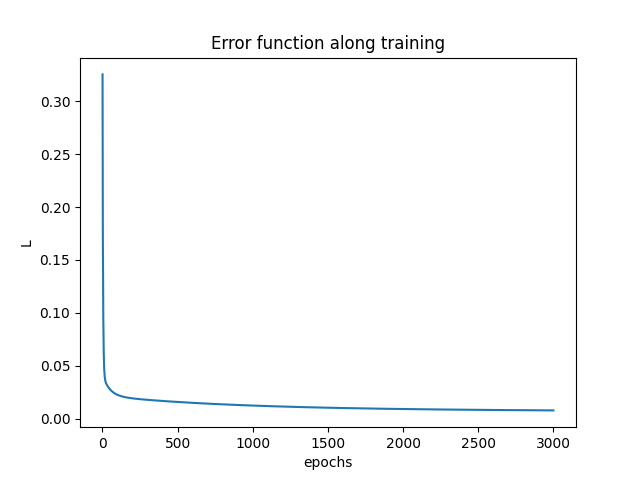

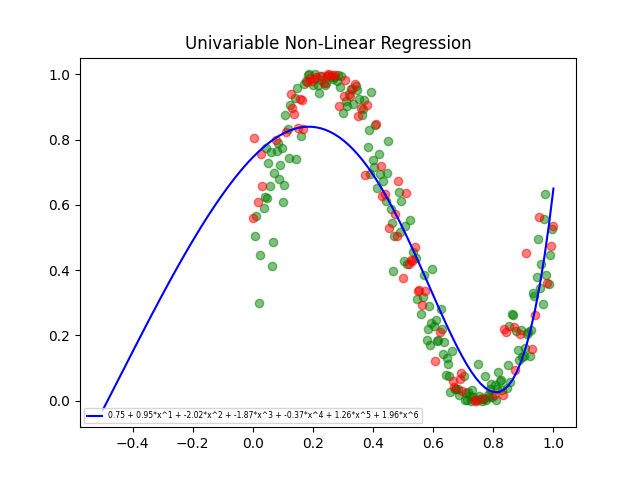

In [80]:
test(extendX, trainY, paramArr, p, lambdita)

## **Referencias**
- [Optimizing gradient descent](https://ruder.io/optimizing-gradient-descent/index.html)
- [Regression loss functions](https://datamonje.com/regression-loss-functions/)
- [Regularization](https://towardsdatascience.com/l1-and-l2-regularization-methods-ce25e7fc831c)